# Student Performance Prediction — Model Explainability

## Objective
Interpret the best-performing trained model using SHAP to understand feature contributions for global and local predictions.

## Environment Setup

In [13]:
import sys
import os

sys.path.append(os.path.abspath(".."))
from student_management.explainability.shap_explainer import explain_single_student, explain_global_model
import shap
import joblib
import numpy as np

In [14]:
shap.initjs()

## Load Trained Best Model

In [15]:
best_model_name = "logistic_tuned"
best_model_path = f"../models/{best_model_name}/model.joblib"

## Local Explainability — Single Student

We analyze feature contributions for one student prediction.

In [16]:
result = explain_single_student(
    model_path=best_model_path,
    data_path="../data/sample_students.csv",
    student_index=0
)

print("Predicted Class:", result["prediction"])

Predicted Class: 0


In [17]:
shap.force_plot(
    result["expected_value"],
    result["shap_values"],
    result["processed_features"],
    feature_names=result["feature_names"]
)

## Global Explainability — Feature Importance

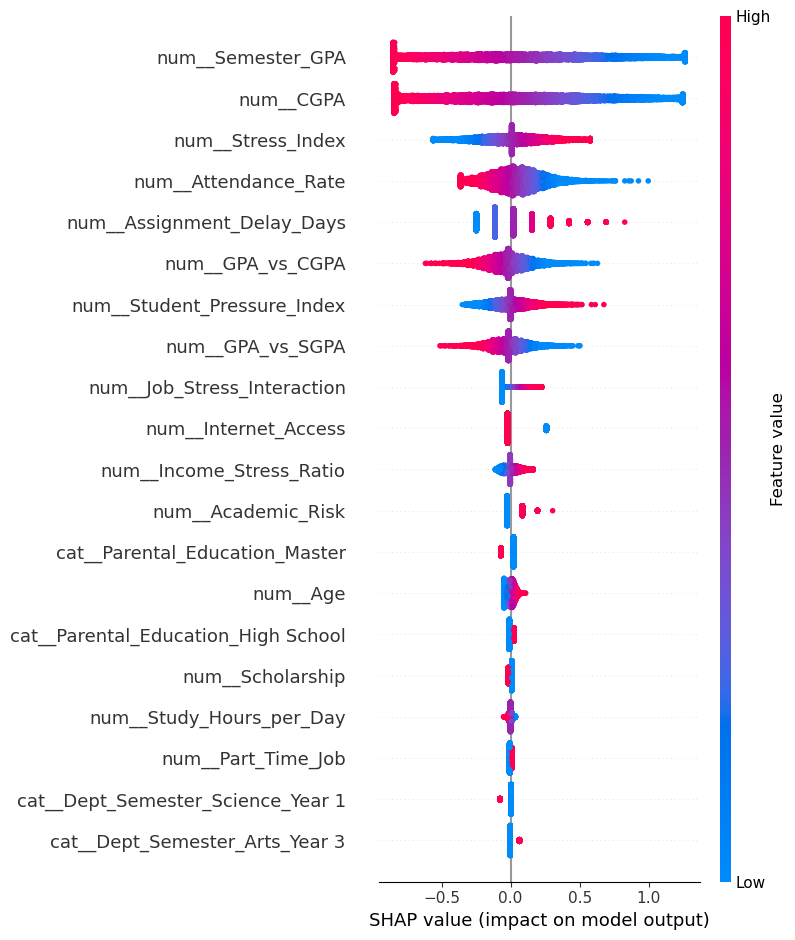

In [19]:
global_result = explain_global_model(
    model_path=best_model_path,
    data_path="../data/sample_students.csv"
)

shap.summary_plot(
    global_result["shap_values"],
    global_result["processed_features"],
    feature_names=global_result["feature_names"]
)